### Import Libraries & Model

In [1]:
import os
import sys
import cv2
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path

# Explicitly set the root directory since __file__ isn't available in Jupyter
root_dir = "/home/vilota/mingjie/dinov3"

# Add the root directory to Python's path so it can find the 'dinov3' module
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from dinov3.hub.backbones import dinov3_vith16plus, Weights
from torch.optim.lr_scheduler import CosineAnnealingLR

import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vilota/.netrc.
wandb: Currently logged in as: mingjiehu5 (mingjiehu5-nanyang-technological-university-singapore) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Wandb Record

In [3]:
# Initialize a new experiment run
wandb.init(
    project="dinov3-blur-detection",  # Group name for your experiments
    name="vith16plus-multiclass-run1", # Name of this specific trial run
    config={
        "architecture": "dinov3_vith16plus",
    }
)

# Optional: You can access these variables anywhere using wandb.config
config = wandb.config

### DINOv3 + Classifier Model

In [ ]:
# ==========================================
# 1. DINOv3 MODEL DEFINITION
# ==========================================

class ResidualBlock(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        return x + self.block(x)


class MaskedEdgeBlurDetector(nn.Module):
    # Added weights_path=None to the arguments
    def __init__(self, backbone_name="dinov3_vith16plus", freeze_backbone=True, num_classes=7, weights_path=None):
        super().__init__()
        
        print(f"Loading DINOv3 Backbone: {backbone_name}...")
        if backbone_name == "dinov3_vith16plus":
            # If a local path is provided, pass it to the weights argument!
            weights_arg = weights_path if weights_path else Weights.LVD1689M
            self.backbone = dinov3_vith16plus(pretrained=True, weights=weights_arg)
        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}")
            
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
                
        embed_dim = self.backbone.embed_dim
        linear_input_dim = 2 * embed_dim 
        
        self.linear_head = nn.Sequential(
            nn.Linear(linear_input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            ResidualBlock(1024),
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes) # Multi-class output
        )


    def forward(self, x, patch_mask):
        features = self.backbone.forward_features(x)
        cls_token = features["x_norm_clstoken"]       
        patch_tokens = features["x_norm_patchtokens"] 
        
        mask_weights = patch_mask.float().unsqueeze(-1)
        weighted_patches = patch_tokens * mask_weights
        
        summed_patches = weighted_patches.sum(dim=1) 
        valid_patch_count = mask_weights.sum(dim=1) + 1e-6
        masked_patch_mean = summed_patches / valid_patch_count 
        
        linear_input = torch.cat([cls_token, masked_patch_mean], dim=1) 
        logits = self.linear_head(linear_input)
        
        return logits


### CV2 Process & Mask Generator

In [5]:
# ==========================================
# 2. DATASET & MASK GENERATOR
# ==========================================
def get_horizontal_patch_mask(image_path, image_size=224, patch_size=16, threshold=50):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}")
        
    img = cv2.resize(img, (image_size, image_size))
    sobel_y = cv2.Sobel(img, cv2.CV_64F, dx=0, dy=1, ksize=3)
    abs_sobel_y = np.absolute(sobel_y)
    sobel_8u = np.uint8(255 * abs_sobel_y / np.max(abs_sobel_y))
    
    _, binary_mask = cv2.threshold(sobel_8u, threshold, 255, cv2.THRESH_BINARY)
    mask_tensor = torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    
    patch_mask_2d = F.max_pool2d(mask_tensor, kernel_size=patch_size, stride=patch_size)
    patch_mask_flat = patch_mask_2d.view(-1) > 0 
    
    return patch_mask_flat

class BlurDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # 1. Process Image
        pil_image = Image.open(img_path).convert("RGB")
        if self.transform:
            pixel_values = self.transform(pil_image)
            
        # 2. Generate Mask
        patch_mask = get_horizontal_patch_mask(img_path)
        
        # 3. Label (0.0 for Sharp, 1.0 for Blur)
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return pixel_values, patch_mask, label_tensor


### Early Stop

In [6]:
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0, save_path="dino_classifier_head_multiclass.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.base_save_path = save_path  
        self.counter = 0
        self.best_precision = 0.0  
        self.early_stop = False

    def __call__(self, val_precision, model_head, epoch):
        if val_precision > (self.best_precision + self.min_delta):
            print(f"-> Validation precision improved ({self.best_precision:.4f} --> {val_precision:.4f}).")
            self.best_precision = val_precision
            self.counter = 0
            
            # Append epoch number dynamically
            path_obj = Path(self.base_save_path)
            new_filename = f"{path_obj.stem}_epoch_{epoch}{path_obj.suffix}"
            current_save_path = str(path_obj.with_name(new_filename))
            
            print(f"Saving classifier head to {current_save_path}")
            torch.save(model_head.state_dict(), current_save_path)
        else:
            self.counter += 1
            print(f"-> EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
from sklearn.metrics import precision_score
from torch.optim.lr_scheduler import CosineAnnealingLR

# ==========================================
# 3. TRAINING LOOP
# ==========================================
def train_model(model, train_loader, val_loader, device, epochs=500, lr=5e-4, save_path="classifier_head.pth"):
    # Heavily penalize missing defects by adjusting the target loss multipliers
    custom_weights = [1.0, 2.0, 2.0, 3.0, 2.0, 2.0, 1.0]
    weights_tensor = torch.FloatTensor(custom_weights).to(device)

    optimizer = torch.optim.AdamW(model.linear_head.parameters(), lr=lr, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    # Initialize the precision-monitoring early stopper
    early_stopper = EarlyStopping(patience=10, save_path=save_path)
    wandb.watch(model.linear_head, log="all", log_freq=10)

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        train_correct = 0
        total_train = 0
        
        for pixel_values, patch_mask, labels in train_loader:
            pixel_values = pixel_values.to(device)
            patch_mask = patch_mask.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            optimizer.zero_grad()
            
            logits = model(pixel_values, patch_mask)
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * pixel_values.size(0)
            
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_acc = train_correct / total_train

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        total_val = 0
        
        # Lists to store metrics across the entire validation dataset for this epoch
        val_preds = []
        val_labels_list = []
        
        with torch.no_grad():
            for pixel_values, patch_mask, labels in val_loader:
                pixel_values = pixel_values.to(device)
                patch_mask = patch_mask.to(device)
                labels = labels.to(device, dtype=torch.long)

                logits = model(pixel_values, patch_mask)
                loss = criterion(logits, labels)
                
                val_loss += loss.item() * pixel_values.size(0)
                
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                total_val += labels.size(0)
                
                # Append arrays to evaluate holistic macro precision metrics
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / total_val
        val_acc = val_correct / total_val
        
        # Calculate precision specifically for the 'o' (OK, index 0) class
        y_true = np.array(val_labels_list)
        y_pred = np.array(val_preds)
        ok_precision = precision_score(y_true == 0, y_pred == 0, pos_label=True, zero_division=0)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f} | "
              f"OK Precision: {ok_precision:.4f}")

        # Update learning rate scheduler steps
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Log metrics safely to the cloud dashboard
        wandb.log({
            "epoch": epoch + 1,
            "train/loss": avg_train_loss,
            "train/accuracy": train_acc,
            "val/loss": avg_val_loss,
            "val/accuracy": val_acc,
            "val/ok_precision": ok_precision,
            "learning_rate": current_lr,
            "early_stopping_counter": early_stopper.counter
        })

        # Evaluate checkpoint against best precision criteria
        early_stopper(ok_precision, model.linear_head, epoch=epoch + 1)

        if early_stopper.early_stop:
            print("Early stopping triggered. Training stopped.")
            break

### Multi Class Mapping

In [8]:
# Define the multi-class mapping based on your human annotations
LABEL_MAP = {
    'o':  0, # ok
    'sf': 1, # slightly far
    'mf': 2, # medium far
    'xf': 3, # extremely far
    'sn': 4, # slightly near
    'mn': 5, # medium near
    'xn': 6  # extremely near
}
NUM_CLASSES = len(LABEL_MAP)

### Data Cleaning & Finding

In [9]:
analysis_positions = [1, 3, 5, 7, 9]

manual_path = "/home/vilota/566-qa-2/619D/IMG/MTF数据表2026-05-07/结果数据-201个总检-2026-05-07 (1)(结果数据).csv"

df = pd.read_csv(manual_path)

df = df.rename(columns={"????": "Capture Time", "??": "Grade", "NG??": "NG", "???": "SN", "??.1": "Short SN Pairing"})
column_to_drop = ['Capture Time', 'Grade', 'NG', 'Short SN Pairing', 'Full SN', '???.1', '???.2', '???_Focus', '???_Focus.1', 'AA?_??S', 'AA?_??S2', 'AA?_??T', 'AA?_??T2', 'AA?_??S.1', 'AA?_??T.1', 'AA?_??S.2', 'AA?_??T.2', 'AA?_??S.3', 'AA?_??T.3', 'AA?_??S.4', 'AA?_??T.4', 'AA?_Tilt-X', 'AA?_Tilt-Y', 'AA?_OC-X', 'AA?_OC-Y', 'AA?_???X', 'AA?_???Y', 'AA?_??0.5F-S', 'AA?_??0.5F-T', 'AA?_??0.5F-S.1', 'AA?_??0.5F-T.1', 'AA?_??0.5F-S.2', 'AA?_??0.5F-T.2', 'AA?_??0.5F-S.3', 'AA?_??0.5F-T.3', 'AA?_????', 'AA?_????.1', 'AA?_????.2', 'AA?_????.3', 'AA?_??0.5??', 'AA?_??0.5??.1', 'AA?_??0.5??.2', 'AA?_??0.5??.3']
df = df.drop(columns=column_to_drop, errors='ignore')
df = df.fillna("o")

pos_columns = ['pos 1', 'pos 3', 'pos 5', 'pos 7', 'pos 9']

for col in pos_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.split('/').str[0].str.strip()

df['SN'] = df['SN'].astype(str).str.split('/').str[0].str.strip().str.upper().str.replace(r'\.0$', '', regex=True)

# ---------------------------------------------------------
# DATA EXTRACTION TO PYTORCH DATASET
# ---------------------------------------------------------
IMAGE_DIR = "/home/vilota/566-qa-2/619D/processed_images" # <-- Update to your master folder

print(f"Recursively indexing all images in {IMAGE_DIR}...")

# Build a dictionary mapping 'filename.ext' -> '/absolute/path/to/nested/folder/filename.ext'
image_path_map = {}
valid_extensions = {'.bmp', '.png', '.jpg', '.jpeg'}

for p in Path(IMAGE_DIR).rglob('*'):
    if p.is_file() and p.suffix.lower() in valid_extensions:
        image_path_map[p.name] = str(p)
        
print(f"Found {len(image_path_map)} total image files across all subfolders.")

valid_images = []
valid_labels = []

# Map from the position number to the column name in df
pos_mapping = {
    1: 'pos 1',
    3: 'pos 3',
    5: 'pos 5',
    7: 'pos 7',
    9: 'pos 9'
}

missing_images = 0
for idx, row in df.iterrows():
    sn = row['SN']
    for pos_num, col_name in pos_mapping.items():
        if col_name in row:
            annotation = str(row[col_name]).strip().lower()
            
            if annotation in LABEL_MAP:
                # Define all possible filename structures for this SN/Pos
                possible_names = [
                    f"{sn}-{pos_num}.bmp",
                    f"{sn}-{pos_num}.png",
                    f"processed_{sn}-{pos_num}.png"
                ]
                
                # Check our index to see if any of these filenames exist anywhere
                found_path = None
                for name in possible_names:
                    if name in image_path_map:
                        found_path = image_path_map[name]
                        break # Found it! Stop checking alternatives.
                
                if found_path:
                    valid_images.append(found_path)
                    valid_labels.append(LABEL_MAP[annotation])
                else:
                    missing_images += 1
                    
if missing_images > 0:
    print(f"Warning: {missing_images} labeled items in the CSV could not be matched to an image file.")
    
if not valid_images:
    raise ValueError("No valid images found! Check your IMAGE_DIR and filename conventions.")

Recursively indexing all images in /home/vilota/566-qa-2/619D/processed_images...
Found 1090 total image files across all subfolders.


### Split Data

In [10]:
X_train, X_val, y_train, y_val = train_test_split(valid_images, valid_labels, test_size=0.2, random_state=42)

print(f"Dataset Loaded: {len(X_train)} Train | {len(X_val)} Validation")

Dataset Loaded: 866 Train | 217 Validation


### Data Loader

In [ ]:
# ---------------------------------------------------------
# TRANSFORMS, DATALOADERS & EXECUTION
# ---------------------------------------------------------
dino_transform = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

train_dataset = BlurDataset(X_train, y_train, transform=dino_transform)
val_dataset = BlurDataset(X_val, y_val, transform=dino_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define where you saved the downloaded .pth file
LOCAL_WEIGHTS = "/home/vilota/mingjie/dinov3/weights/dinov3_vith16plus_pretrain_lvd1689m-7c1da9a5.pth" 

model = MaskedEdgeBlurDetector(
    backbone_name="dinov3_vith16plus", 
    freeze_backbone=True, 
    num_classes=NUM_CLASSES,
    weights_path=LOCAL_WEIGHTS  # <-- Pass the local path here
).to(device)

Using device: cuda
Loading DINOv3 Backbone: dinov3_vith16plus...


### Start Training

In [12]:
print("\nStarting Training...")
train_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    epochs=500, 
    lr=1e-2, 
    save_path=f"dino_classifier_head_multiclass.pth"
)


Starting Training...
Epoch [1/500] | Train Loss: 1.3553, Acc: 0.7055 | Val Loss: 1.2505, Acc: 0.5576 | OK Precision: 0.8413
-> Validation precision improved (0.0000 --> 0.8413).
Saving classifier head to dino_classifier_head_multiclass_epoch_1.pth
Epoch [2/500] | Train Loss: 1.1598, Acc: 0.7079 | Val Loss: 1.1932, Acc: 0.5023 | OK Precision: 0.9130
-> Validation precision improved (0.8413 --> 0.9130).
Saving classifier head to dino_classifier_head_multiclass_epoch_2.pth
Epoch [3/500] | Train Loss: 1.0392, Acc: 0.7182 | Val Loss: 1.0830, Acc: 0.7558 | OK Precision: 0.8281
-> EarlyStopping counter: 1 out of 30
Epoch [4/500] | Train Loss: 0.9865, Acc: 0.7575 | Val Loss: 1.1551, Acc: 0.8018 | OK Precision: 0.8238
-> EarlyStopping counter: 2 out of 30
Epoch [5/500] | Train Loss: 0.8528, Acc: 0.7875 | Val Loss: 0.8690, Acc: 0.7834 | OK Precision: 0.8571
-> EarlyStopping counter: 3 out of 30
Epoch [6/500] | Train Loss: 0.8330, Acc: 0.7829 | Val Loss: 0.8558, Acc: 0.8018 | OK Precision: 0.877

### Confusion Matrix

Running inference on the validation set...

--- Classification Report ---
              precision    recall  f1-score   support

           o       0.88      0.84      0.86       177
          sf       0.20      0.33      0.25         3
          mf       0.00      0.00      0.00         0
          xf       0.00      0.00      0.00         0
          sn       0.36      0.48      0.41        29
          mn       0.20      0.20      0.20         5
          xn       0.00      0.00      0.00         3

    accuracy                           0.76       217
   macro avg       0.23      0.26      0.25       217
weighted avg       0.77      0.76      0.76       217



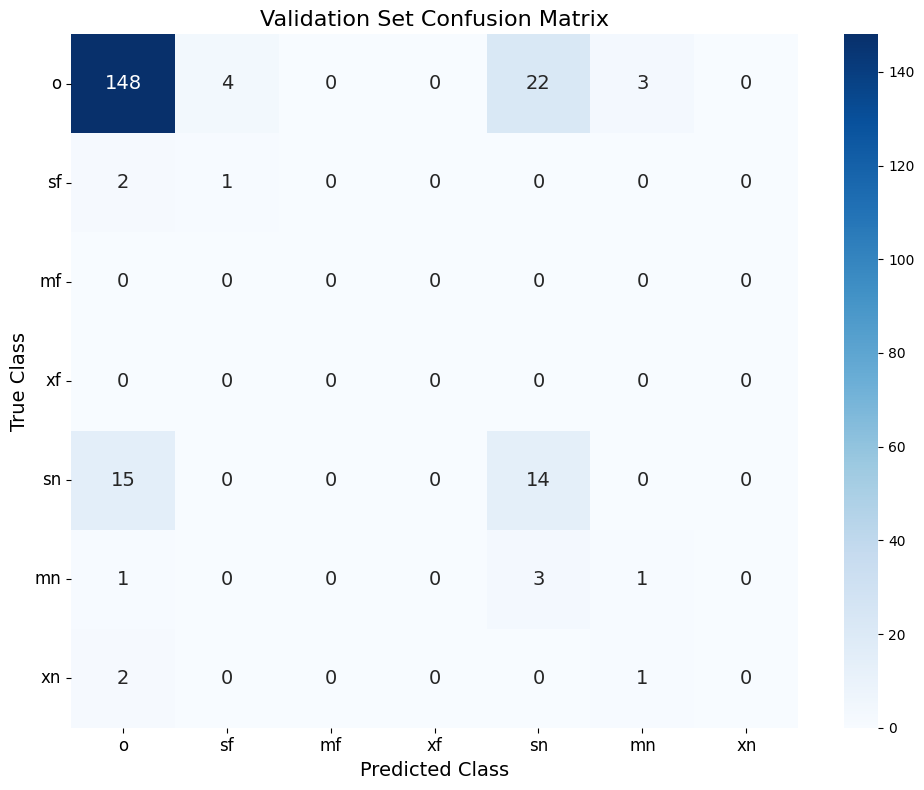

early_stopping_counter,▁▁▁▂▂▃▃▄▄▄▅▆▆▆▁▂▂▂▃▃▅▅▅▆▆▁▂▂▂▁▂▃▃▄▄▅▅▆▇█
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
learning_rate,███████████▇▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▁▁▁
train/accuracy,▁▁▄▄▄▄▄▅▅▅▅▆▆▅▆▆▆▇▆▇▆▆▇▇▇▇▇█▇▇█▇▇▇▇██▆██
train/loss,█▇▆▄▄▃▄▃▃▃▃▃▃▃▂▂▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁▂▁▁▁▁
val/accuracy,▁▇▇▄▇▅█▅▇▅▄▆█▆▆▇▆▇▇▆▆▇▇▄▅▅▇▅▆▄▇▅▅▅▇▆▅▇▄▅
val/loss,▄▄▄▂▂▁▂▂▂▁▃▂▃▁▂▂▂▂▁▂▃▂▂▁▂▃▃▂▃▃▂▂▄▄▂▄▂▃▄█
val/ok_precision,▂▆▁▄▄▅▃▃▅▄▃▅▄▄▅▆▄▄▅▆▄▅▇▆▅▅▄█▄▆▄▆▅▄▄▆▆█▆▆
early_stopping_counter,29
epoch,88
learning_rate,0.00926


<Figure size 640x480 with 0 Axes>

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Ensure the model is in evaluation mode
model.eval()

# 2. Lists to store all our predictions and actual ground truths
all_preds = []
all_labels = []

print("Running inference on the validation set...")

# 3. Pass the val_loader through the model without tracking gradients
with torch.no_grad():
    for pixel_values, patch_mask, labels in val_loader:
        pixel_values = pixel_values.to(device)
        patch_mask = patch_mask.to(device)
        
        # Get raw logits
        logits = model(pixel_values, patch_mask)
        
        # Get the predicted class index
        preds = torch.argmax(logits, dim=1)
        
        # Move back to CPU and append to our lists
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Define the exact class names and their corresponding index (0 to 6)
class_names = ['o', 'sf', 'mf', 'xf', 'sn', 'mn', 'xn']
class_indices = [0, 1, 2, 3, 4, 5, 6]

# 4. Print the Classification Report
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, 
                            labels=class_indices,       # <--- ADDED THIS
                            target_names=class_names, 
                            zero_division=0))

# 5. Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=class_indices) # <--- ADDED THIS

# 6. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            annot_kws={"size": 14}) # Make numbers larger

plt.title('Validation Set Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('True Class', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

wandb.log({"validation_confusion_matrix": wandb.Image(plt)})

wandb.finish()

### Predict Unseen Dataset